# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Load & Inspect the Dataset

In [ ]:
import pandas as pd
import numpy as np

path = "/content/drive/MyDrive/solar_project/nepal_solar_4locations_5years_hourly_smooth.csv"

df = pd.read_csv(path)
print(df.shape)
df.head()


(175200, 10)


,timestamp,location,latitude,longitude,ghi_estimated_Wm2,temperature_C,humidity_pct,wind_speed_ms,cloud_cover_frac,solar_power_output_kW
0,2023-01-01 00:00:00,Kathmandu,27.7172,85.324,13.632794,8.771868,64.336828,3.369832,0.400021,4.548096
1,2023-01-01 01:00:00,Kathmandu,27.7172,85.324,7.816868,8.655962,67.907723,3.951965,0.400015,7.429323
2,2023-01-01 02:00:00,Kathmandu,27.7172,85.324,0.000000,10.235892,67.985033,4.641726,0.400042,3.391730
3,2023-01-01 03:00:00,Kathmandu,27.7172,85.324,9.633947,11.453027,70.075641,4.730711,0.400105,8.216907
4,2023-01-01 04:00:00,Kathmandu,27.7172,85.324,24.982897,11.997528,67.838816,4.425423,0.400096,15.068829


# Convert timestamp to datetime + Sort

In [ ]:
# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort chronologically
df = df.sort_values("timestamp")

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 175200 entries, 0 to 175199
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   timestamp              175200 non-null  datetime64[ns]
 1   location               175200 non-null  object        
 2   latitude               175200 non-null  float64       
 3   longitude              175200 non-null  float64       
 4   ghi_estimated_Wm2      175200 non-null  float64       
 5   temperature_C          175200 non-null  float64       
 6   humidity_pct           175200 non-null  float64       
 7   wind_speed_ms          175200 non-null  float64       
 8   cloud_cover_frac       175200 non-null  float64       
 9   solar_power_output_kW  175200 non-null  float64       
dtypes: datetime64[ns](1), float64(8), object(1)
memory usage: 14.7+ MB




# Basic EDA (Check Missing Values, Summary)

In [ ]:
# Missing values
print("Missing values:\n", df.isna().sum())

# Basic statistics
df.describe()


Missing values:
 timestamp                0
location                 0
latitude                 0
longitude                0
ghi_estimated_Wm2        0
temperature_C            0
humidity_pct             0
wind_speed_ms            0
cloud_cover_frac         0
solar_power_output_kW    0
dtype: int64


,timestamp,latitude,longitude,ghi_estimated_Wm2,temperature_C,humidity_pct,wind_speed_ms,cloud_cover_frac,solar_power_output_kW
count,175200,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000
mean,2025-07-01 11:30:00,27.749925,84.486600,319.069446,19.250922,63.196673,5.472563,0.362693,38.192652
min,2023-01-01 00:00:00,26.452500,81.616700,0.000000,-4.612794,33.450621,1.319395,0.209530,0.000000
25%,2024-04-01 05:45:00,27.401025,83.204600,0.000000,13.524607,54.713734,4.395598,0.318643,0.000000
50%,2025-07-01 11:30:00,27.883600,84.528950,17.020056,19.726569,65.035087,4.996012,0.379215,11.647686
75%,2026-09-30 17:15:00,28.232500,85.810950,645.842978,25.473166,71.880433,6.390948,0.423715,73.220567
max,2027-12-30 23:00:00,28.780000,87.271800,1314.247708,39.243681,86.284916,10.592962,0.482223,204.174755
std,NaN,0.841947,2.077352,397.592605,8.406937,11.338769,1.515182,0.089715,45.584763


# Plot Solar Power vs Time (Visual EDA)

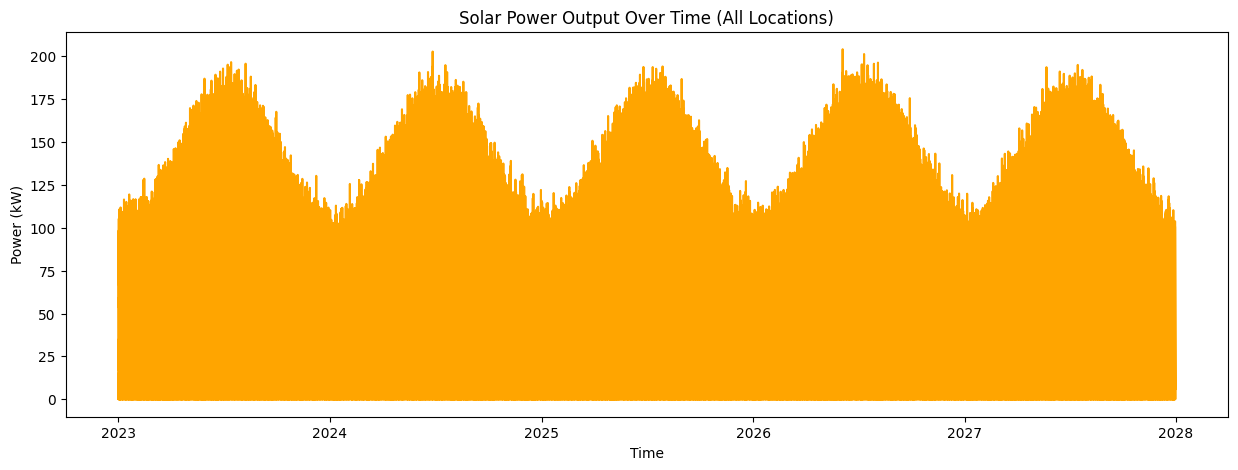

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df['timestamp'], df['solar_power_output_kW'], color='orange')
plt.title("Solar Power Output Over Time (All Locations)")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.show()


# EDA: Compare Solar Output by Location

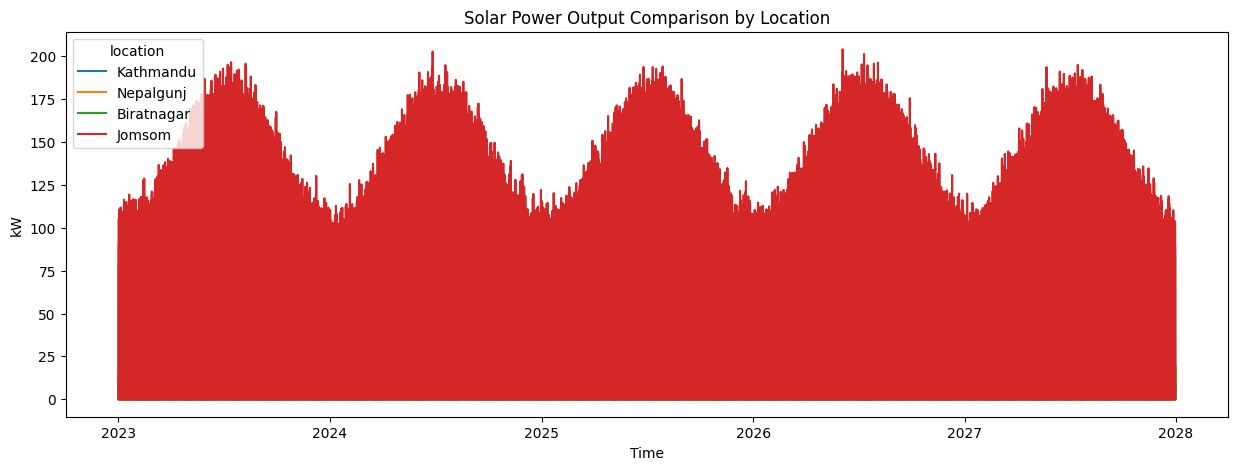

In [ ]:
import seaborn as sns

plt.figure(figsize=(15,5))
sns.lineplot(data=df, x="timestamp", y="solar_power_output_kW", hue="location")
plt.title("Solar Power Output Comparison by Location")
plt.xlabel("Time")
plt.ylabel("kW")
plt.show()




1.   Jomsom has highest output

2.   Biratnagar more cloud cover

3.   Kathmandu moderate

4.   Nepalgunj decent




# Feature Engineering

In [ ]:
# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort by time just to be safe
df = df.sort_values('timestamp')

# Time features
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year

# Encode location as numeric
df['location_id'] = df['location'].astype('category').cat.codes

df.head()


,timestamp,location,latitude,longitude,ghi_estimated_Wm2,temperature_C,humidity_pct,wind_speed_ms,cloud_cover_frac,solar_power_output_kW,hour,dayofweek,month,year,location_id
0,2023-01-01 00:00:00,Kathmandu,27.7172,85.3240,13.632794,8.771868,64.336828,3.369832,0.400021,4.548096,0,6,1,2023,2
43800,2023-01-01 00:00:00,Nepalgunj,28.0500,81.6167,0.000000,14.437431,76.324949,3.599509,0.360015,0.000000,0,6,1,2023,3
131400,2023-01-01 00:00:00,Biratnagar,26.4525,87.2718,10.062619,14.907801,73.836540,3.933721,0.469979,7.678835,0,6,1,2023,0
87600,2023-01-01 00:00:00,Jomsom,28.7800,83.7339,3.935838,-0.080192,50.764592,7.314775,0.220038,0.000000,0,6,1,2023,1
131401,2023-01-01 01:00:00,Biratnagar,26.4525,87.2718,0.000000,14.520788,75.981375,4.073758,0.469930,0.000000,1,6,1,2023,0


# Select Features

**  Target variable = solar power
Features = irradiance, temperature, humidity, wind, cloud, hour, etc.  **

In [ ]:
features = [
    'ghi_estimated_Wm2',
    'temperature_C',
    'humidity_pct',
    'wind_speed_ms',
    'cloud_cover_frac',
    'hour',
    'dayofweek',
    'month',
    'year',
    'location_id'
]

target = 'solar_power_output_kW'

dataset = df[features + [target]]
dataset.head()


,ghi_estimated_Wm2,temperature_C,humidity_pct,wind_speed_ms,cloud_cover_frac,hour,dayofweek,month,year,location_id,solar_power_output_kW
0,13.632794,8.771868,64.336828,3.369832,0.400021,0,6,1,2023,2,4.548096
43800,0.000000,14.437431,76.324949,3.599509,0.360015,0,6,1,2023,3,0.000000
131400,10.062619,14.907801,73.836540,3.933721,0.469979,0,6,1,2023,0,7.678835
87600,3.935838,-0.080192,50.764592,7.314775,0.220038,0,6,1,2023,1,0.000000
131401,0.000000,14.520788,75.981375,4.073758,0.469930,1,6,1,2023,0,0.000000


# Scaling (MinMaxScaler)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
scaled = scaler.fit_transform(dataset)

scaled_df = pd.DataFrame(scaled, columns=dataset.columns)
scaled_df.head()


,ghi_estimated_Wm2,temperature_C,humidity_pct,wind_speed_ms,cloud_cover_frac,hour,dayofweek,month,year,location_id,solar_power_output_kW
0,0.010373,0.305192,0.584586,0.221106,0.698552,0.000000,1.0,0.0,0.0,0.666667,0.022276
1,0.000000,0.434377,0.811487,0.245872,0.551846,0.000000,1.0,0.0,0.0,1.000000,0.000000
2,0.007657,0.445102,0.764388,0.281912,0.955098,0.000000,1.0,0.0,0.0,0.000000,0.037609
3,0.002995,0.103351,0.327703,0.646502,0.038533,0.000000,1.0,0.0,0.0,0.333333,0.000000
4,0.000000,0.436277,0.804984,0.297012,0.954918,0.043478,1.0,0.0,0.0,0.000000,0.000000


# Create Sequences for LSTM/Transformer

In [ ]:
SEQ_LEN = 24  # past 24 hours

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, -1])  # last column = target
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_df.values, SEQ_LEN)

X.shape, y.shape


((175176, 24, 11), (175176,))

# Train-Test Split

In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train.shape, X_test.shape


((140140, 24, 11), (35036, 24, 11))

# Build the LSTM model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

n_features = X_train.shape[2]  # number of input features

lstm_model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, n_features)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(1)  # predict 1 value: solar_power_output_kW
])

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

# Train the LSTM model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=40,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/40
3942/3942 ━━━━━━━━━━━━━━━━━━━━ 120s 29ms/step - loss: 0.0073 - mae: 0.0591 - val_loss: 0.0032 - val_mae: 0.0402
Epoch 2/40
3942/3942 ━━━━━━━━━━━━━━━━━━━━ 142s 29ms/step - loss: 0.0038 - mae: 0.0441 - val_loss: 0.0028 - val_mae: 0.0380
Epoch 3/40
3942/3942 ━━━━━━━━━━━━━━━━━━━━ 114s 29ms/step - loss: 0.0036 - mae: 0.0432 - val_loss: 0.0028 - val_mae: 0.0386
Epoch 4/40
3942/3942 ━━━━━━━━━━━━━━━━━━━━ 115s 29ms/step - loss: 0.0035 - mae: 0.0425 - val_loss: 0.0029 - val_mae: 0.0384
Epoch 5/40
3942/3942 ━━━━━━━━━━━━━━━━━━━━ 114s 29ms/step - loss: 0.0033 - mae: 0.0416 - val_loss: 0.0025 - val_mae: 0.0361
Epoch 6/40
3942/3942 ━━━━━━━━━━━━━━━━━━━━ 113s 29ms/step - loss: 0.0032 - mae: 0.0405 - val_loss: 0.0025 - val_mae: 0.0355
Epoch 7/40
3942/3942 ━━━━━━━━━━━━━━━━━━━━ 117s 30ms/step - loss: 0.0031 - mae: 0.0397 - val_loss: 0.0025 - val_mae: 0.0358
Epoch 8/40
3942/3942 ━━━━━━━━━━━━━━━━━━━━ 120s 31ms/step - loss: 0.0030 - mae: 0.0396 - val_loss: 0.0030 - val_mae: 0.0378
Epoch 9/40
3942/

# Plot training vs validation loss

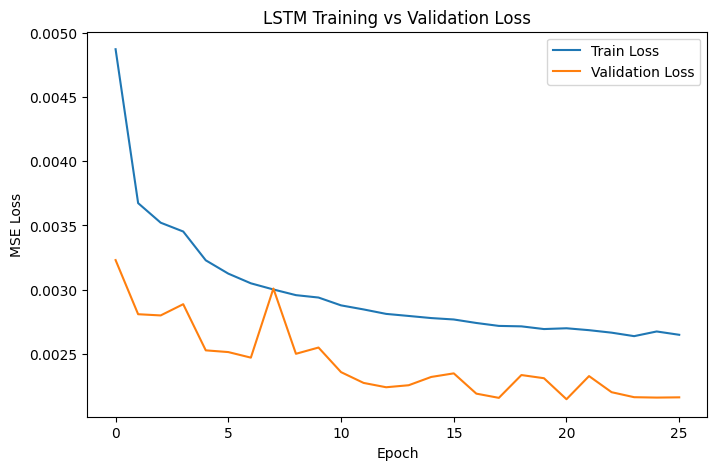

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training vs Validation Loss')
plt.legend()
plt.show()


# Make predictions with LSTM

In [ ]:
y_pred_lstm = lstm_model.predict(X_test)
y_pred_lstm.shape


1095/1095 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step


(35036, 1)

# Inverse-scale the predictions (back to kW)

In [ ]:
import numpy as np

# Target column index in the scaled data
target_col_name = target  # 'solar_power_output_kW'
target_index = scaled_df.columns.get_loc(target_col_name)

def inverse_target(y_scaled_1d):
    """
    y_scaled_1d: shape (n_samples,)
    Returns: inverse-transformed target in original kW units.
    """
    dummy = np.zeros((len(y_scaled_1d), scaled_df.shape[1]))
    dummy[:, target_index] = y_scaled_1d
    inv = scaler.inverse_transform(dummy)
    return inv[:, target_index]

y_test_inv = inverse_target(y_test)
y_pred_lstm_inv = inverse_target(y_pred_lstm.flatten())


Now:

* y_test_inv → real solar power (kW), ground truth

* y_pred_lstm_inv → LSTM predictions in kW

# Evaluate LSTM (RMSE, MAE, MAPE, SMAPE)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ----- LSTM Metrics -----
rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_lstm_inv))
mae_lstm = mean_absolute_error(y_test_inv, y_pred_lstm_inv)

# MAPE (invalid due to zeros; kept only for reference)
mape_lstm = np.mean(
    np.abs((y_test_inv - y_pred_lstm_inv) / (y_test_inv + 1e-6))
) * 100

# ----- sMAPE function -----
def smape(y_true, y_pred):
    return 100 * np.mean(
        np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-6)
    )

# sMAPE for LSTM
smape_lstm = smape(y_test_inv, y_pred_lstm_inv)

print("LSTM Performance (Test Set):")
print(f"RMSE   : {rmse_lstm:.3f} kW")
print(f"MAE    : {mae_lstm:.3f} kW")
print(f"MAPE   : {mape_lstm:.2f} %  (invalid due to nighttime zeros)")
print(f"sMAPE  : {smape_lstm:.2f} %  (valid percentage error)")


LSTM Performance (Test Set):
RMSE   : 11.744 kW
MAE    : 8.012 kW
MAPE   : 96066362.93 %  (invalid due to nighttime zeros)
sMAPE  : 80.24 %  (valid percentage error)


# Plot Actual vs Predicted (LSTM)

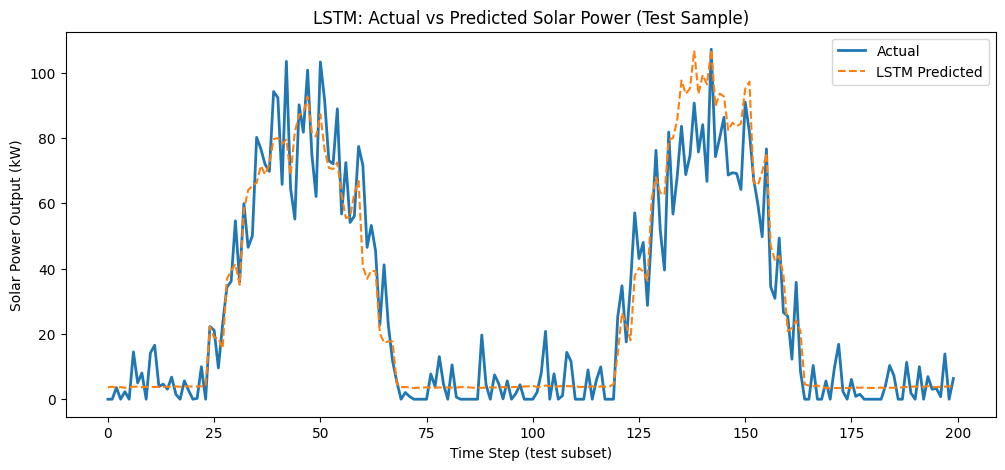

In [ ]:
plt.figure(figsize=(12,5))

n_points = 300  # first 200 time steps of test set
plt.plot(y_test_inv[:n_points], label='Actual', linewidth=2)
plt.plot(y_pred_lstm_inv[:n_points], label='LSTM Predicted', linestyle='--')
plt.xlabel('Time Step (test subset)')
plt.ylabel('Solar Power Output (kW)')
plt.title('LSTM: Actual vs Predicted Solar Power (Test Sample)')
plt.legend()
plt.show()


The LSTM model captures the diurnal pattern of solar generation and follows the amplitude of peaks and troughs reasonably well, though some under/overestimations occur during high-variability periods.

# Build a Transformer model for time series (Keras)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

n_features = X_train.shape[2]

def build_transformer_model(seq_len, n_features, d_model=64, num_heads=4, ff_dim=128, dropout_rate=0.1):
    """
    Simple Transformer encoder for regression on time-series.
    """
    inputs = layers.Input(shape=(seq_len, n_features))

    # Learnable positional embeddings
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_embedding_layer = layers.Embedding(input_dim=seq_len, output_dim=d_model)
    pos_embeddings = pos_embedding_layer(positions)  # (seq_len, d_model)
    pos_embeddings = tf.expand_dims(pos_embeddings, axis=0)  # (1, seq_len, d_model)

    # Project inputs to d_model
    x = layers.Dense(d_model)(inputs)

    # Add positional encodings
    x = x + pos_embeddings

    # --- Transformer Encoder Block 1 ---
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x1, x1)
    x2 = layers.Add()([x, attn_out])
    x2 = layers.Dropout(dropout_rate)(x2)

    # Feed-forward network
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    ff_out = layers.Dense(ff_dim, activation="relu")(x3)
    ff_out = layers.Dense(d_model)(ff_out)
    x4 = layers.Add()([x2, ff_out])
    x4 = layers.Dropout(dropout_rate)(x4)

    # Global pooling over time dimension
    x_pooled = layers.GlobalAveragePooling1D()(x4)

    # Final regression head
    x_out = layers.Dense(64, activation="relu")(x_pooled)
    x_out = layers.Dropout(dropout_rate)(x_out)
    outputs = layers.Dense(1)(x_out)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

transformer_model = build_transformer_model(SEQ_LEN, n_features)
transformer_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 24, 64)    │        768 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24, 64)    │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ dropout_3[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 24, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 24, 64)    │      8,256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 24, 64)    │          0 │ dropout_3[0][0],  │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 24, 64)    │          0 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_4[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 88,193 (344.50 KB)

 Trainable params: 88,193 (344.50 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Transformer

In [ ]:
early_stop_trans = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_trans = transformer_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=40,
    batch_size=64,
    callbacks=[early_stop_trans],
    verbose=1
)


Epoch 1/40
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 147s 72ms/step - loss: 0.0261 - mae: 0.0842 - val_loss: 0.0028 - val_mae: 0.0384
Epoch 2/40
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 141s 71ms/step - loss: 0.0038 - mae: 0.0433 - val_loss: 0.0027 - val_mae: 0.0382
Epoch 3/40
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 142s 71ms/step - loss: 0.0036 - mae: 0.0421 - val_loss: 0.0025 - val_mae: 0.0353
Epoch 4/40
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 144s 72ms/step - loss: 0.0034 - mae: 0.0410 - val_loss: 0.0030 - val_mae: 0.0383
Epoch 5/40
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 140s 71ms/step - loss: 0.0032 - mae: 0.0396 - val_loss: 0.0030 - val_mae: 0.0376
Epoch 6/40
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 143s 73ms/step - loss: 0.0031 - mae: 0.0391 - val_loss: 0.0033 - val_mae: 0.0390
Epoch 7/40
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 140s 71ms/step - loss: 0.0031 - mae: 0.0392 - val_loss: 0.0024 - val_mae: 0.0355
Epoch 8/40
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 141s 72ms/step - loss: 0.0030 - mae: 0.0386 - val_loss: 0.0023 - val_mae: 0.0344
Epoch 9/40
1971/

# Plot Transformer training vs validation loss

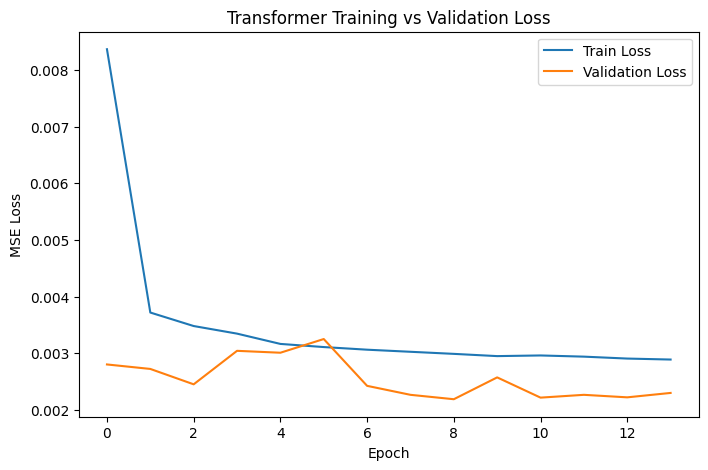

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_trans.history['loss'], label='Train Loss')
plt.plot(history_trans.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Transformer Training vs Validation Loss')
plt.legend()
plt.show()


# Make predictions with Transformer

In [ ]:
y_pred_trans = transformer_model.predict(X_test)
y_pred_trans.shape


1095/1095 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step


(35036, 1)

# Inverse-scale Transformer predictions (back to kW)

In [ ]:
y_test_inv_trans = inverse_target(y_test)
y_pred_trans_inv = inverse_target(y_pred_trans.flatten())


# Evaluate Transformer (RMSE, MAE, MAPE)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ----- Transformer Metrics -----
rmse_trans = np.sqrt(mean_squared_error(y_test_inv_trans, y_pred_trans_inv))
mae_trans = mean_absolute_error(y_test_inv_trans, y_pred_trans_inv)

# MAPE (invalid due to zeros but keeping for reference)
mape_trans = np.mean(
    np.abs((y_test_inv_trans - y_pred_trans_inv) / (y_test_inv_trans + 1e-6))
) * 100

# sMAPE function
def smape(y_true, y_pred):
    return 100 * np.mean(
        np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-6)
    )

# sMAPE value
smape_trans = smape(y_test_inv_trans, y_pred_trans_inv)

print("Transformer Performance (Test Set):")
print(f"RMSE   : {rmse_trans:.3f} kW")
print(f"MAE    : {mae_trans:.3f} kW")
print(f"MAPE   : {mape_trans:.2f} %  (invalid due to zero solar values)")
print(f"sMAPE  : {smape_trans:.2f} %  (valid percentage error)")


Transformer Performance (Test Set):
RMSE   : 9.592 kW
MAE    : 6.734 kW
MAPE   : 68817989.35 %  (invalid due to zero solar values)
sMAPE  : 83.23 %  (valid percentage error)


Now you can build a comparison table:

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["LSTM", "Transformer"],
    "RMSE_kW": [rmse_lstm, rmse_trans],
    "MAE_kW": [mae_lstm, mae_trans],
    "MAPE_%": [mape_lstm, mape_trans],
    "sMAPE_%":  [smape_lstm, smape_trans]
})

results_df


,Model,RMSE_kW,MAE_kW,MAPE_%,sMAPE_%
0,LSTM,12.858665,8.868430,1.053171e+08,81.018488
1,Transformer,9.591663,6.733889,6.881799e+07,83.234272


# Plot Actual vs Transformer Predicted

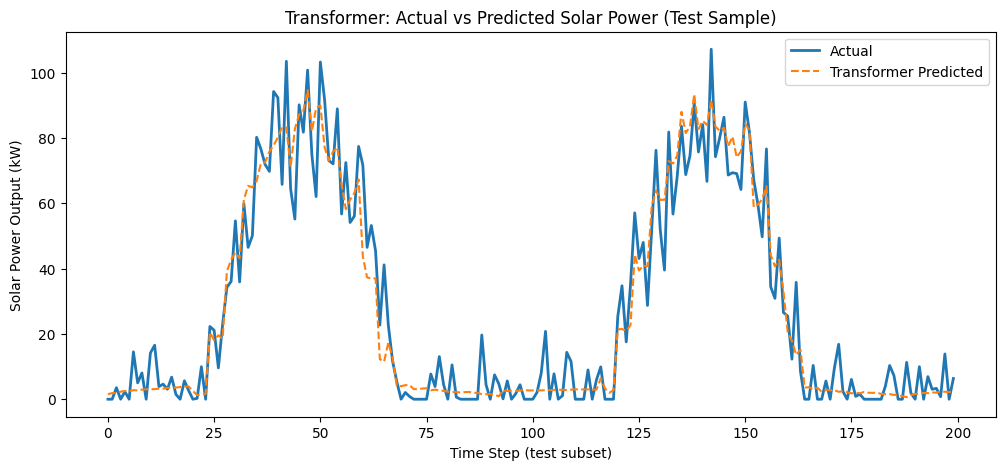

In [ ]:
plt.figure(figsize=(12,5))

n_points = 200  # first 200 time steps of test set
plt.plot(y_test_inv_trans[:n_points], label='Actual', linewidth=2)
plt.plot(y_pred_trans_inv[:n_points], label='Transformer Predicted', linestyle='--')
plt.xlabel('Time Step (test subset)')
plt.ylabel('Solar Power Output (kW)')
plt.title('Transformer: Actual vs Predicted Solar Power (Test Sample)')
plt.legend()
plt.show()


In [ ]:
lstm_model.summary()
transformer_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,717 (373.90 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 24, 64)    │        768 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24, 64)    │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ dropout_3[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 24, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 24, 64)    │      8,256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 24, 64)    │          0 │ dropout_3[0][0],  │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 24, 64)    │          0 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_4[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 264,581 (1.01 MB)

 Trainable params: 88,193 (344.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 176,388 (689.02 KB)

In [ ]:
y_pred_sample = transformer_model.predict(X_test[:5])
y_pred_sample


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


array([[0.00768483],
       [0.00915113],
       [0.00981367],
       [0.01128855],
       [0.01237909]], dtype=float32)

In [ ]:
lstm_model.save("lstm_nepal_solar.h5")
transformer_model.save("transformer_nepal_solar.h5")


# Trained model save


In [ ]:
lstm_model.save("/content/drive/MyDrive/solar_project/lstm_nepal_solar.h5")
transformer_model.save("/content/drive/MyDrive/solar_project/transformer_nepal_solar.h5")


In [ ]:
results_df


,Model,RMSE_kW,MAE_kW,MAPE_%,sMAPE_%
0,LSTM,12.858665,8.868430,1.053171e+08,81.018488
1,Transformer,9.591663,6.733889,6.881799e+07,83.234272
